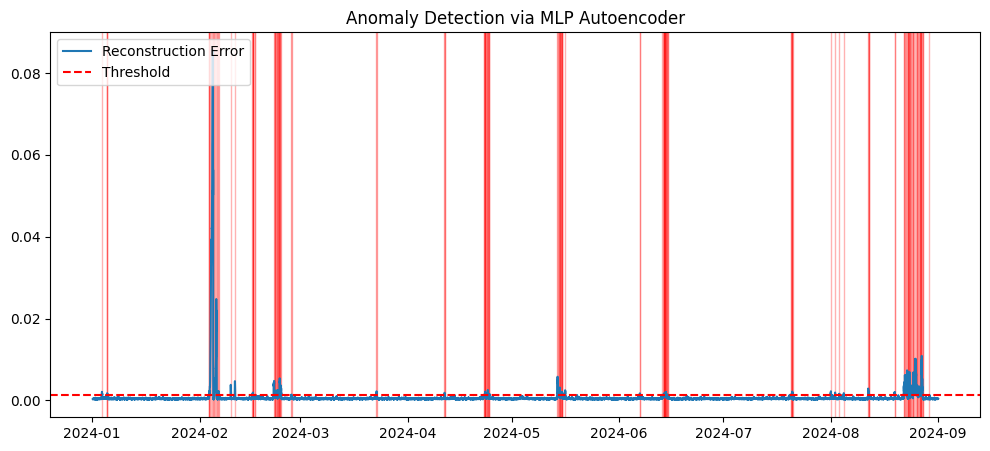

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Data_longer/BSM2-ASReactor2-Faulty.csv", index_col=0, parse_dates=True)

# Use 2023 data as clean training data
train_mask = (df.index.year == 2023)
train_data = df[train_mask]
test_data = df[~train_mask]

# Normalize using training data only
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Create sliding windows
def create_windows(data, window_size):
    X = []
    for i in range(len(data) - window_size + 1):
        X.append(data[i:i+window_size].flatten())
    return np.array(X)

window_size = 16  # ~4 hours
X_train = create_windows(train_scaled, window_size)
X_test = create_windows(test_scaled, window_size)

# Fit a simple MLP autoencoder
model = MLPRegressor(hidden_layer_sizes=(128, 64, 128), max_iter=100, random_state=0)
model.fit(X_train, X_train)

# Predict and calculate reconstruction error on test set
X_test_pred = model.predict(X_test)
mse = np.mean((X_test - X_test_pred)**2, axis=1)

# Threshold and anomaly detection
threshold = np.percentile(mse, 95)
anomalies = mse > threshold

# Group consecutive anomalies
from itertools import groupby
from datetime import timedelta

timestamps = test_data.index[window_size - 1:]
anomaly_times = timestamps[anomalies]

# Group by gaps > 1 step
anomaly_groups = []
group = [anomaly_times[0]]
for i in range(1, len(anomaly_times)):
    if (anomaly_times[i] - anomaly_times[i-1]) > timedelta(minutes=15):
        anomaly_groups.append(group)
        group = []
    group.append(anomaly_times[i])
if group:
    anomaly_groups.append(group)

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(timestamps, mse, label="Reconstruction Error")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
for group in anomaly_groups:
    plt.axvspan(group[0], group[-1], color='red', alpha=0.3)
plt.legend()
plt.title("Anomaly Detection via MLP Autoencoder")
plt.show()


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from datetime import timedelta

# === Load data ===
df = pd.read_csv("Data_longer/BSM2-ASReactor2-Faulty.csv", index_col=0, parse_dates=True)
fault_log = pd.read_csv("Data_longer/BSM2-ASReactor2-FaultLog.csv", parse_dates=["StartTime", "EndTime"])
fault_log = fault_log[fault_log['Type'] != 'noise'].copy()
# === Prepare training and test data ===
train_mask = df.index.year == 2023
train_data = df[train_mask]
test_data = df[~train_mask]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# === Create sliding windows ===
def create_windows(data, window_size):
    return np.array([data[i:i + window_size] for i in range(len(data) - window_size + 1)])

window_size = 16  # 160 minutes
X_train = create_windows(train_scaled, window_size)
X_test = create_windows(test_scaled, window_size)
timestamps = test_data.index[window_size - 1:]

X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# === Train Autoencoder ===
model = MLPRegressor(hidden_layer_sizes=(128, 64, 128), max_iter=100, random_state=0)
model.fit(X_train_flat, X_train_flat)
X_test_pred = model.predict(X_test_flat).reshape(X_test.shape)

# === Reconstruction error (per-variable) ===
recon_error = np.mean((X_test - X_test_pred)**2, axis=1)  # shape: (n_windows, n_variables)
thresholds = np.percentile(recon_error, 98, axis=0)
anomaly_flags = (recon_error > thresholds).any(axis=1)
anomaly_cause = pd.DataFrame(recon_error > thresholds, index=timestamps, columns=df.columns)

# === Group anomalous windows ===
anomaly_times = timestamps[anomaly_flags]
anomaly_groups = []
if len(anomaly_times) > 0:
    group = [anomaly_times[0]]
    for i in range(1, len(anomaly_times)):
        if (anomaly_times[i] - anomaly_times[i - 1]) > timedelta(minutes=15):
            anomaly_groups.append(group)
            group = []
        group.append(anomaly_times[i])
    if group:
        anomaly_groups.append(group)

# === Ground Truth Anomaly Window Construction ===
ground_truth = pd.DataFrame(False, index=timestamps, columns=df.columns)
for _, row in fault_log.iterrows():
    affected = (timestamps >= row["StartTime"]) & (timestamps <= row["EndTime"])
    if row["Variable"] in ground_truth.columns:
        ground_truth.loc[affected, row["Variable"]] = True

# === Compute Accuracy Metrics Per Variable ===
metrics = {}
for var in df.columns:
    y_true = ground_truth[var].values
    y_pred = anomaly_cause[var].values
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    metrics[var] = {
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
metrics_df = pd.DataFrame(metrics).T
print("=== Detection Accuracy per Variable ===")
print(metrics_df)

# === Plotting Example: Choose One Variable ===
var = "FlowRate"  # change this to the variable you want to inspect
var_idx = list(df.columns).index(var)
original = test_data[var].iloc[window_size - 1:]
recon_err = recon_error[:, var_idx]
threshold = thresholds[var_idx]
flags = recon_err > threshold
gt_flags = ground_truth[var].values

# === Plot ===
plt.figure(figsize=(14, 6))

# Top: original signal
plt.subplot(2, 1, 1)
plt.plot(timestamps, original, label=f"Original {var}")
plt.fill_between(timestamps, original.min(), original.max(), where=gt_flags,
                 color='green', alpha=0.3, label="Ground Truth")
plt.fill_between(timestamps, original.min(), original.max(), where=flags,
                 color='red', alpha=0.3, label="Detected Anomaly")
plt.title(f"{var} - Signal with Anomaly Highlights")
start_date = pd.Timestamp("2024-03-01")
end_date = pd.Timestamp("2024-05-31")
plt.xlim(start_date, end_date)
plt.ylabel(var)
plt.legend()
plt.grid(True)

# Bottom: reconstruction error
plt.subplot(2, 1, 2)
plt.plot(timestamps, recon_err, label="Reconstruction Error", color='orange')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.fill_between(timestamps, 0, recon_err.max(), where=gt_flags,
                 color='green', alpha=0.2)
plt.fill_between(timestamps, 0, recon_err.max(), where=flags,
                 color='red', alpha=0.2)
plt.title(f"{var} - Reconstruction Error & Anomalies")
plt.ylabel("Error")
plt.xlabel("Time")
start_date = pd.Timestamp("2024-03-01")
end_date = pd.Timestamp("2024-05-31")
plt.xlim(start_date, end_date)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print(threshold)

C:\Users\zzhao3\AppData\Local\Temp\ipykernel_8612\4258170047.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fault_log = pd.read_csv("Data_longer/BSM2-ASReactor2-FaultLog.csv", parse_dates=["StartTime", "EndTime"])
C:\Users\zzhao3\AppData\Local\Temp\ipykernel_8612\4258170047.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fault_log = pd.read_csv("Data_longer/BSM2-ASReactor2-FaultLog.csv", parse_dates=["StartTime", "EndTime"])


TypeError: Invalid comparison between dtype=datetime64[ns] and str

=== Detection Accuracy per Variable ===
             Precision    Recall  F1 Score
FlowRate      0.319058  0.218689  0.259507
Temperature   0.052309  0.351805  0.091077
SO            0.135900  0.163043  0.148240
SNO           0.114754  0.059222  0.078125
SNH           0.032220  0.078110  0.045621
SS            0.000000  0.000000  0.000000


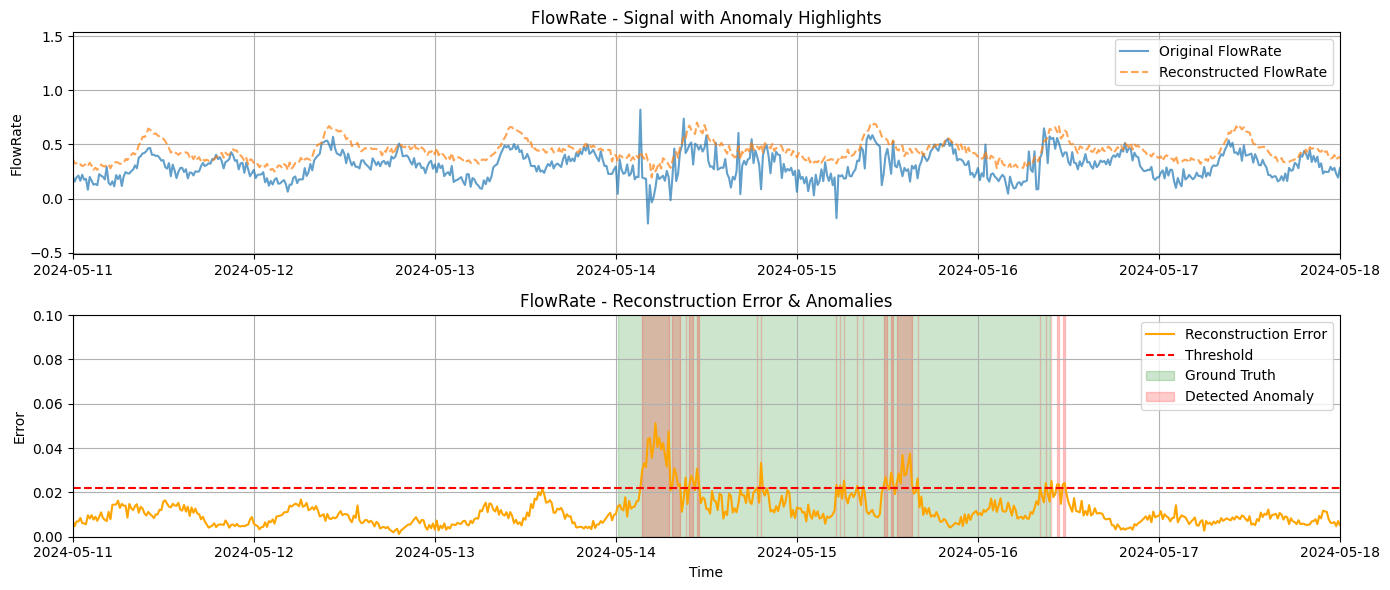

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from datetime import timedelta

# === Load data ===
df = pd.read_csv("Data_longer/BSM2-ASReactor2-Faulty.csv", index_col=0, parse_dates=True)
fault_log = pd.read_csv("Data_longer/FaultLog_with_datetimes.csv", parse_dates=["startdate", "enddate"])
fault_log = fault_log[fault_log['Type'] != 'noise'].copy()

# === Prepare training and test data ===
train_mask = (df.index.month >= 7) & (df.index.month <= 11) & (df.index.year == 2023)
test_mask = df.index.year == 2024

train_data = df[train_mask]
test_data = df[test_mask]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# === Create sliding windows ===
def create_windows(data, window_size):
    return np.array([data[i:i + window_size] for i in range(len(data) - window_size + 1)])

window_size = 16  # 160 minutes
X_train = create_windows(train_scaled, window_size)
X_test = create_windows(test_scaled, window_size)
timestamps = test_data.index[window_size - 1:]

X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# === Train Autoencoder ===
model = MLPRegressor(hidden_layer_sizes=(128, 64, 128), max_iter=100, random_state=0)
model.fit(X_train_flat, X_train_flat)
X_test_pred = model.predict(X_test_flat).reshape(X_test.shape)

# === Compute reconstruction error (per-variable) ===
X_train_pred = model.predict(X_train_flat).reshape(X_train.shape)
train_error = np.mean((X_train - X_train_pred)**2, axis=1)
recon_error = np.mean((X_test - X_test_pred)**2, axis=1)

# === Compute threshold based on training set: 1.5 × mean error per variable ===
train_error_per_var = np.mean((X_train - X_train_pred)**2, axis=(0, 1)) 

# thresholds = 60 * train_error_per_var
threshold = 0.022   # <-- this is the one you defined

anomaly_flags = (recon_error > threshold).any(axis=1)
anomaly_cause = pd.DataFrame(recon_error > threshold, index=timestamps, columns=df.columns)

# === Group anomalous windows ===
anomaly_times = timestamps[anomaly_flags]
anomaly_groups = []
if len(anomaly_times) > 0:
    group = [anomaly_times[0]]
    for i in range(1, len(anomaly_times)):
        if (anomaly_times[i] - anomaly_times[i - 1]) > timedelta(minutes=15):
            anomaly_groups.append(group)
            group = []
        group.append(anomaly_times[i])
    if group:
        anomaly_groups.append(group)

# === Ground Truth Anomaly Window Construction ===
ground_truth = pd.DataFrame(False, index=timestamps, columns=df.columns)
for _, row in fault_log.iterrows():
    affected = (timestamps >= row["startdate"]) & (timestamps <= row["enddate"])
    if row["Variable"] in ground_truth.columns:
        ground_truth.loc[affected, row["Variable"]] = True

# === Compute Accuracy Metrics Per Variable ===
metrics = {}
for var in df.columns:
    y_true = ground_truth[var].values
    y_pred = anomaly_cause[var].values
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    metrics[var] = {
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
metrics_df = pd.DataFrame(metrics).T
print("=== Detection Accuracy per Variable ===")
print(metrics_df)

# === Plotting Example: Choose One Variable ===
var = "FlowRate"  # Change as needed
var_idx = list(df.columns).index(var)
original = test_data[var].iloc[window_size - 1:]
recon_err = recon_error[:, var_idx]
# threshold = thresholds[var_idx]
flags = recon_err > threshold
gt_flags = ground_truth[var].values

# === Plot ===
plt.figure(figsize=(14, 6))
original_df = pd.read_csv("Data_longer/BSM2-ASReactor2-Faulty.csv", index_col=0, parse_dates=True)
original_scaled = scaler.transform(original_df)

# Convert scaled numpy array back to DataFrame for easy handling:
original_scaled_df = pd.DataFrame(original_scaled, columns=original_df.columns, index=original_df.index)

original_scaled_var = original_scaled_df[var]
predicted_df = pd.read_csv("Data_longer/reconstructed_full_timeline.csv", index_col=0, parse_dates=True)


# Extract original and prediction series aligned by index
original = original_df[var]
prediction = predicted_df[var]
errors = (original - prediction) ** 2

# Use mean error as threshold (you can also use 1.5×mean or mean+std if needed)
# threshold = errors.mean()
threshold = 0.022
# Top: original signal
plt.subplot(2, 1, 1)
plt.plot(original.index, original_scaled_var, label=f"Original {var}", alpha=0.7)
plt.plot(prediction.index, prediction, label=f"Reconstructed {var}", alpha=0.7, linestyle='--')

# plt.fill_between(timestamps, original_scaled_var.min(), original_scaled_var.max(), where=gt_flags,
#                  color='green', alpha=0.3, label="Ground Truth")
# plt.fill_between(timestamps, original.min(), original.max(), where=flags,
#                  color='red', alpha=0.3, label="Detected Anomaly")
plt.title(f"{var} - Signal with Anomaly Highlights")
start_date = pd.Timestamp("2024-05-11")
end_date = pd.Timestamp("2024-05-18")
plt.xlim(start_date, end_date)
plt.ylabel(var)
plt.legend()
plt.grid(True)

# Bottom: reconstruction error
plt.subplot(2, 1, 2)
plt.plot(timestamps, recon_err, label="Reconstruction Error", color='orange')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.fill_between(timestamps, 0, recon_err.max(), where=gt_flags,
                 color='green', alpha=0.2,label="Ground Truth")
plt.fill_between(timestamps, 0, recon_err.max(), where=flags,
                 color='red', alpha=0.2,label="Detected Anomaly")
plt.title(f"{var} - Reconstruction Error & Anomalies")
plt.ylabel("Error")
plt.xlabel("Time")
start_date = pd.Timestamp("2024-05-11")
end_date = pd.Timestamp("2024-05-18")
plt.xlim(start_date, end_date)
plt.ylim(0,0.1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
# # Full index (all timestamps from original data)
# full_index = df.index

# # Create empty DataFrame with zeros for all variables and full index length
# reconstructed_full_df = pd.DataFrame(0, index=full_index, columns=df.columns)

# # Insert reconstructed values ONLY for timestamps where you have predictions (test period with windows)
# reconstructed_full_df.loc[timestamps, :] = reconstructed_flat[:, -1, :]

# # Save to CSV
# reconstructed_full_df.to_csv("reconstructed_full_timeline.csv")



In [ ]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots